In [9]:
!pip install gensim
import nltk
import spacy
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import treebank
from nltk.tag import hmm,brill,brill_trainer

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('universal_tagset')
nltk.download('treebank')

[nltk_data] Downloading package punkt to /Users/mac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/mac/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/mac/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /Users/mac/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package treebank to /Users/mac/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [33]:
#POS tagging

In [10]:
sentence = "John saw the saw and decided to take it to the table."


print(" NLTK POS Tagging ")
tokens = nltk.word_tokenize(sentence)
nltk_tags = nltk.pos_tag(tokens)

for word, tag in nltk_tags:
    print(f"{word:10} -> {tag}")

print("\nSpaCy POS Tagging ")
nlp = spacy.load("en_core_web_sm")
doc = nlp(sentence)

for token in doc:
    print(f"{token.text:10} -> {token.pos_:6} ({token.tag_} {spacy.explain(token.tag_)})")

 NLTK POS Tagging 
John       -> NNP
saw        -> VBD
the        -> DT
saw        -> NN
and        -> CC
decided    -> VBD
to         -> TO
take       -> VB
it         -> PRP
to         -> TO
the        -> DT
table      -> NN
.          -> .

SpaCy POS Tagging 
John       -> PROPN  (NNP noun, proper singular)
saw        -> VERB   (VBD verb, past tense)
the        -> DET    (DT determiner)
saw        -> NOUN   (NN noun, singular or mass)
and        -> CCONJ  (CC conjunction, coordinating)
decided    -> VERB   (VBD verb, past tense)
to         -> PART   (TO infinitival "to")
take       -> VERB   (VB verb, base form)
it         -> PRON   (PRP pronoun, personal)
to         -> ADP    (IN conjunction, subordinating or preposition)
the        -> DET    (DT determiner)
table      -> NOUN   (NN noun, singular or mass)
.          -> PUNCT  (. punctuation mark, sentence closer)


In [35]:
#Ambiguity Handling

In [11]:
sentences=[
    "I like candy.",
    "Time flies like an arrow."
]


print(" Ambiguity Analysis \n")

for sent in sentences:
    print(f"Sentence: {sent}")
    
   
    nltk_tags = nltk.pos_tag(nltk.word_tokenize(sent))
    print("NLTK :", nltk_tags)
    
   
    doc = nlp(sent)
    spacy_tags = [(t.text, t.pos_) for t in doc]
    print("SpaCy:", spacy_tags)
    
    print()

 Ambiguity Analysis 

Sentence: I like candy.
NLTK : [('I', 'PRP'), ('like', 'VBP'), ('candy', 'NN'), ('.', '.')]
SpaCy: [('I', 'PRON'), ('like', 'VERB'), ('candy', 'NOUN'), ('.', 'PUNCT')]

Sentence: Time flies like an arrow.
NLTK : [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), ('.', '.')]
SpaCy: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('an', 'DET'), ('arrow', 'NOUN'), ('.', 'PUNCT')]



In [37]:
 #Rule based vs Ml based Tagging

In [12]:
from nltk.tag import hmm

data=treebank.tagged_sents()
split_idx=int(len(data)*0.9)
train_data=data[:split_idx]
test_data=data[split_idx:]

print(f"Training set: {len(train_data)} sentences")
print(f"Testing set: {len(test_data)} sentences")


default_tagger=nltk.DefaultTagger('NN')
unigram_tagger=nltk.UnigramTagger(train_data,backoff=default_tagger)

templates=brill.fntbl37()
trainer=brill_trainer.BrillTaggerTrainer(unigram_tagger,templates)
brill_tagger=trainer.train(train_data,max_rules=200)

acc_brill=brill_tagger.accuracy(test_data)
print(f"\nRule-Based (Brill) Accuracy: {acc_brill:.2%}")


trainer_hmm=hmm.HiddenMarkovModelTrainer()
hmm_tagger=trainer_hmm.train_supervised(train_data)
acc_hmm=hmm_tagger.accuracy(test_data)
print(f"ML-Based (HMM) Accuracy:{acc_hmm:.2%}")

print("\n--- Comparison ---")
print(f"Rule-Based Accuracy: {acc_brill:.2%}")
print(f"ML-Based Accuracy: {acc_hmm:.2%}")

Training set: 3522 sentences
Testing set: 392 sentences

Rule-Based (Brill) Accuracy: 90.63%


/opt/miniconda3/envs/nlp310/lib/python3.10/site-packages/nltk/tag/hmm.py:333: RuntimeWarning: overflow encountered in cast
  X[i, j] = self._transitions[si].logprob(self._states[j])
/opt/miniconda3/envs/nlp310/lib/python3.10/site-packages/nltk/tag/hmm.py:335: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])
/opt/miniconda3/envs/nlp310/lib/python3.10/site-packages/nltk/tag/hmm.py:331: RuntimeWarning: overflow encountered in cast
  P[i] = self._priors.logprob(si)
/opt/miniconda3/envs/nlp310/lib/python3.10/site-packages/nltk/tag/hmm.py:363: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])


ML-Based (HMM) Accuracy:42.55%

--- Comparison ---
Rule-Based Accuracy: 90.63%
ML-Based Accuracy: 42.55%


In [39]:
#Implement a Multi-Layer Perceptron (MLP) for Classification

--- MLP Classifier ---
Model accuracy on make_Moons: 88.50%


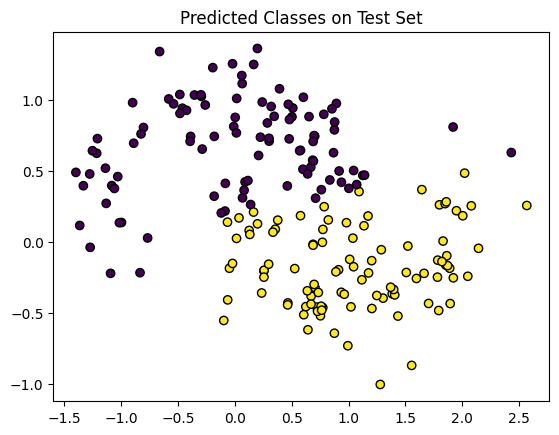

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X,y=make_moons(n_samples=1000,noise=0.2,random_state=42)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

mlp=MLPClassifier(hidden_layer_sizes=(10,),
                  activation='relu',
                  solver='adam',
                  max_iter=1000,
                  random_state=42)
mlp.fit(X_train,y_train)

Y_pred=mlp.predict(X_test)
accuracy=accuracy_score(y_test,Y_pred)
print("--- MLP Classifier ---")
print(f"Model accuracy on make_Moons: {accuracy:.2%}")

plt.scatter(X_test[:,0],X_test[:,1],c=Y_pred,cmap='viridis',edgecolor='k')
plt.title("Predicted Classes on Test Set")
plt.show()

In [41]:
#Implement Back Propogation from Scratch

In [14]:
import numpy as np


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])


inp = 2
hid = 4
out = 1

np.random.seed(0)

W1 = np.random.randn(inp, hid)
b1 = np.zeros((1, hid))
W2 = np.random.randn(hid, out)
b2 = np.zeros((1, out))

lr = 0.1

for epoch in range(5000):

   
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    outp = sigmoid(z2)


    error = y - outp

   
    d2 = error * sigmoid_deriv(outp)
    d1 = (d2 @ W2.T) * sigmoid_deriv(a1)

   
    W2 += a1.T @ d2 * lr
    b2 += np.sum(d2, axis=0, keepdims=True) * lr
    W1 += X.T @ d1 * lr
    b1 += np.sum(d1, axis=0, keepdims=True) * lr

    if epoch % 1000 == 0:
        loss = np.mean(error**2)
        print("Epoch", epoch, "Loss", loss)

print("\nFinal Predictions:")
print(outp)

Epoch 0 Loss 0.3266821523682062
Epoch 1000 Loss 0.2185620376267389
Epoch 2000 Loss 0.1528920106011006
Epoch 3000 Loss 0.04247154571448665
Epoch 4000 Loss 0.014422999240721948

Final Predictions:
[[0.08343925]
 [0.91213168]
 [0.91942033]
 [0.09843791]]


In [15]:
# Implement CBOW and Skip-gram from Word2Vec with Gensim

In [16]:
from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize,word_tokenize
import nltk

text="""Natural language processing (NLP) is a machine learning technology that gives computers 
the ability to interpret, manipulate, and comprehend human language. 
NLP combines computational linguistics with statistical, machine learning, and deep learning models. 
Machine learning is great. Deep learning is a subset of machine learning."""

nltk.download('punkt')
sentences=sent_tokenize(text)
tokenized_data=[word_tokenize(sent.lower()) for sent in sentences]

print("--- Word2Vec ---")

model_cbow=Word2Vec(sentences=tokenized_data, vector_size=10,window=5,min_count=1,sg=0)
print("CBOW Model Trained.")

model_skipgram=Word2Vec(sentences=tokenized_data,vector_size=10,window=5,min_count=1,sg=1)
print("Skip-gram Model Trained.")

word = "learning"
print(f"\nMost similar words to '{word}' (CBOW):")
try:
    print(model_cbow.wv.most_similar(word))
except KeyError:
    print(f"Word '{word}' not in vocabulary.")

print(f"\nMost similar words to '{word}' (Skip-gram):")
try:
    print(model_skipgram.wv.most_similar(word))
except KeyError:
    print(f"Word '{word}' not in vocabulary.")

--- Word2Vec ---
CBOW Model Trained.
Skip-gram Model Trained.

Most similar words to 'learning' (CBOW):
[('processing', 0.7158124446868896), ('.', 0.5435342788696289), ('manipulate', 0.5126518607139587), ('of', 0.43307578563690186), ('computers', 0.4034433662891388), ('nlp', 0.3797975778579712), ('gives', 0.36712905764579773), (',', 0.30297496914863586), ('subset', 0.2283681333065033), ('computational', 0.17376931011676788)]

Most similar words to 'learning' (Skip-gram):
[('processing', 0.7206355333328247), ('.', 0.5434513688087463), ('manipulate', 0.5178104043006897), ('of', 0.4333893954753876), ('computers', 0.41369664669036865), ('nlp', 0.38367992639541626), ('gives', 0.37750551104545593), (',', 0.31198522448539734), ('subset', 0.2337576001882553), ('computational', 0.16774040460586548)]


[nltk_data] Downloading package punkt to /Users/mac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
